# Стационаризация 6 временных рядов (ADF + KPSS)

В этом ноутбуке для каждого ряда:

1. Загружаем данные и приводим к `pandas.Series` с временным индексом  
2. Смотрим график исходного ряда  
3. Проверяем стационарность (тесты **ADF** и **KPSS**)  
4. Делаем ряд стационарным автоматическим пайплайном:
   - (опционально) `log`-преобразование для положительных рядов с растущей дисперсией/масштабом  
   - разность 1-го порядка  
   - сезонная разность (для месячных/недельных/дневных рядов)  
5. Повторяем тесты и визуализации «до/после», сохраняем итоговую серию

> Критерий “считаем стационарным” в этом ноутбуке: **ADF p-value < 0.05** и **KPSS p-value > 0.05**.  
> Иногда тесты могут давать противоречия — тогда смотрим на график и ACF/PACF.


In [7]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


In [20]:
def parse_month_index(s: pd.Series) -> pd.DatetimeIndex:
    # Ожидаем формат YYYY-MM
    return pd.to_datetime(s, format="%Y-%m")

def parse_day_index(s: pd.Series) -> pd.DatetimeIndex:
    return pd.to_datetime(s)

def parse_iso_week_index(s: pd.Series) -> pd.DatetimeIndex:
    # Ожидаем формат YYYY-Www (например 1971-W27)
    # Превращаем в понедельник соответствующей недели (ISO)
    return pd.to_datetime(s.astype(str) + "-1", format="%G-W%V-%u")

def stationarity_tests(x: pd.Series, regression: str = "c") -> dict:
    '''
    Возвращает результаты ADF и KPSS.
    regression:
      - 'c'  : константа
      - 'ct' : константа + тренд
    '''
    x = x.dropna()
    out = {}

    adf = adfuller(x.values, regression=regression, autolag="AIC")
    out["adf_stat"] = adf[0]
    out["adf_p"] = adf[1]

    # KPSS: H0 = стационарен. Для тренд-стационарности используйте regression='ct'
    k = kpss(x.values, regression=("c" if regression == "c" else "ct"), nlags="auto")
    out["kpss_stat"] = k[0]
    out["kpss_p"] = k[1]
    return out

def is_positive(x: pd.Series) -> bool:
    x = x.dropna()
    return (x > 0).all()

def scale_ratio(x: pd.Series) -> float:
    x = x.dropna()
    if len(x) == 0:
        return np.nan
    mn = x.min()
    mx = x.max()
    if mn <= 0:
        return np.inf
    return float(mx / mn)

def maybe_log_transform(x: pd.Series):
    '''
    Простая эвристика:
    - если ряд строго положительный
    - и у него большой масштаб/разброс (max/min > 3 или std/mean > 0.5)
    тогда делаем log.
    '''
    x2 = x.copy()
    if not is_positive(x2):
        return x2, "none"
    rr = scale_ratio(x2)
    cv = float(x2.std() / (x2.mean() + 1e-12))
    if (rr > 3) or (cv > 0.5):
        return np.log(x2), "log"
    return x2, "none"

def make_stationary(y: pd.Series, seasonal_period: int | None = None, regression: str = "c") -> dict:
    '''
    Автоматический пайплайн стационаризации.
    Возвращает словарь с промежуточными и итоговыми рядами, а также описанием шагов.
    '''
    steps = []
    cur = y.astype(float).copy()

    # 0) log (если нужно)
    cur2, log_flag = maybe_log_transform(cur)
    if log_flag == "log":
        cur = cur2
        steps.append("log")

    def ok(x: pd.Series):
        res = stationarity_tests(x, regression=regression)
        return (res["adf_p"] < 0.05) and (res["kpss_p"] > 0.05), res

    ok0, res0 = ok(cur)
    tests_history = [("after_" + ("_".join(steps) if steps else "raw"), res0)]

    if ok0:
        return {"raw": y, "stationary": cur, "steps": steps, "tests": tests_history}

    # 1) первая разность
    cur = cur.diff()
    steps.append("diff1")
    ok1, res1 = ok(cur)
    tests_history.append(("after_" + "_".join(steps), res1))
    if ok1:
        return {"raw": y, "stationary": cur, "steps": steps, "tests": tests_history}

    # 2) сезонная разность (если задан период)
    if seasonal_period is not None and seasonal_period > 1:
        cur = cur.diff(seasonal_period)
        steps.append(f"seasdiff{seasonal_period}")
        ok2, res2 = ok(cur)
        tests_history.append(("after_" + "_".join(steps), res2))
        if ok2:
            return {"raw": y, "stationary": cur, "steps": steps, "tests": tests_history}

    # 3) ещё одна первая разность (редко, но бывает)
    cur = cur.diff()
    steps.append("diff1_again")
    ok3, res3 = ok(cur)
    tests_history.append(("after_" + "_".join(steps), res3))

    return {"raw": y, "stationary": cur, "steps": steps, "tests": tests_history}

def plot_before_after(raw: pd.Series, st: pd.Series, title: str):
    fig, ax = plt.subplots(figsize=(12, 4))
    raw.plot(ax=ax)
    ax.set_title(f"{title} — исходный ряд")
    ax.grid(True)
    plt.show()

    fig, ax = plt.subplots(figsize=(12, 4))
    st.dropna().plot(ax=ax)
    ax.set_title(f"{title} — после преобразований (стационаризация)")
    ax.grid(True)
    plt.show()

def plot_acf_pacf(x, lags=40, title=""):
    x = pd.Series(x).dropna()
    n = len(x)

    # ограничение для PACF: nlags < n/2
    max_lags = max(1, min(lags, (n // 2) - 1))
    if max_lags < lags:
        print(f"[{title}] lags={lags} -> using {max_lags} (n={n})")

    fig = plt.figure(figsize=(12, 4))
    plot_acf(x, ax=plt.gca(), lags=max_lags)
    plt.title(f"ACF {title}")
    plt.grid(True)
    plt.show()

    fig = plt.figure(figsize=(12, 4))
    plot_pacf(x, ax=plt.gca(), lags=max_lags, method="ywm")
    plt.title(f"PACF {title}")
    plt.grid(True)
    plt.show()

def pretty_tests(t: dict) -> str:
    return (
        f"ADF: stat={t['adf_stat']:.3f}, p={t['adf_p']:.4f} | "
        f"KPSS: stat={t['kpss_stat']:.3f}, p={t['kpss_p']:.4f}"
    )

def load_series(path: str) -> pd.Series:
    df = pd.read_csv(path)
    base = os.path.basename(path)

    if base.startswith("monthly-") or base in ["international-airline-passengers.csv", "mean-monthly-air-temperature-deg.csv"]:
        idx = parse_month_index(df.iloc[:, 0])
        ser = pd.Series(df.iloc[:, 1].values, index=idx, name=df.columns[1])
        ser = ser.asfreq("MS")  # monthly start
        return ser

    if base.startswith("weekly-"):
        idx = parse_iso_week_index(df.iloc[:, 0])
        ser = pd.Series(df.iloc[:, 1].values, index=idx, name=df.columns[1])
        ser = ser.asfreq("W-MON")  # week starting Monday
        return ser

    if base.startswith("daily-"):
        idx = pd.to_datetime(df.iloc[:, 0])
        ser = pd.Series(df.iloc[:, 1].values, index=idx, name=df.columns[1])
        ser = ser.asfreq("D")
        return ser

    # fallback
    idx = pd.to_datetime(df.iloc[:, 0], errors="coerce")
    ser = pd.Series(df.iloc[:, 1].values, index=idx, name=df.columns[1])
    return ser


In [18]:
from pathlib import Path

PROJECT_DIR = Path.cwd().parent                # D:\Projects\Project_neto_time
RAW_DIR = PROJECT_DIR / "data" / "raw"         # D:\Projects\Project_neto_time\data\raw

paths = {
    "Monthly Sales of Company X": RAW_DIR / "monthly-sales-of-company-x-jan-6.csv",
    "Monthly Boston Armed Robberies": RAW_DIR / "monthly-boston-armed-robberies-j.csv",
    "International Airline Passengers": RAW_DIR / "international-airline-passengers.csv",
    "Mean Monthly Air Temperature": RAW_DIR / "mean-monthly-air-temperature-deg.csv",
    "Weekly Closings of the Dow Jones": RAW_DIR / "weekly-closings-of-the-dowjones-.csv",
    "Daily Total Female Births (CA)": RAW_DIR / "daily-total-female-births-in-cal.csv",
}

missing = {k: str(v) for k, v in paths.items() if not Path(v).exists()}
print("RAW_DIR:", RAW_DIR, "exists:", RAW_DIR.exists())
print("Missing files:", missing)

RAW_DIR: d:\Projects\Project_neto_time\data\raw exists: True
Missing files: {}


Monthly Sales of Company X
Файл: monthly-sales-of-company-x-jan-6.csv | Длина: 77 | Частота: MS | Seasonal period: 12
Исходный ряд: ADF: stat=0.655, p=0.9889 | KPSS: stat=0.852, p=0.0100
Шаги: log -> diff1
Итог: ADF: stat=-3.136, p=0.0240 | KPSS: stat=0.027, p=0.1000


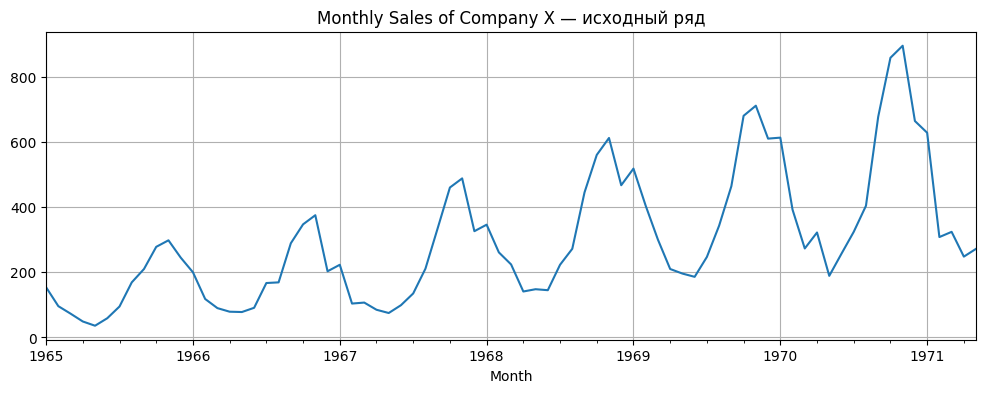

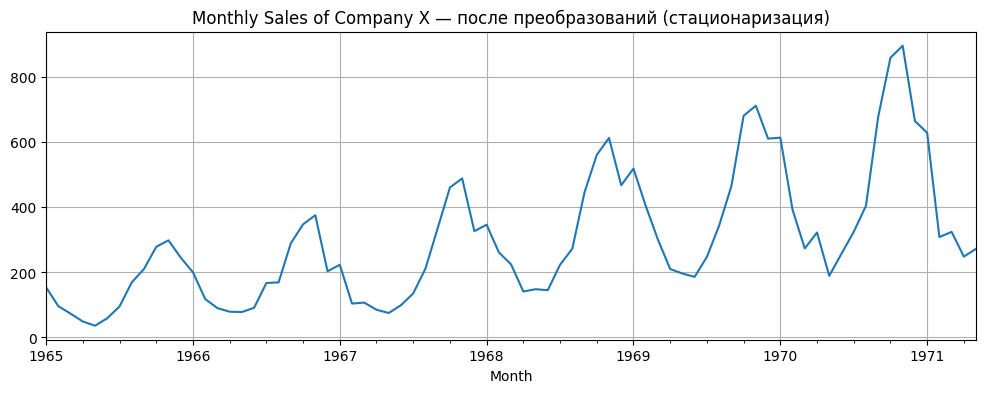

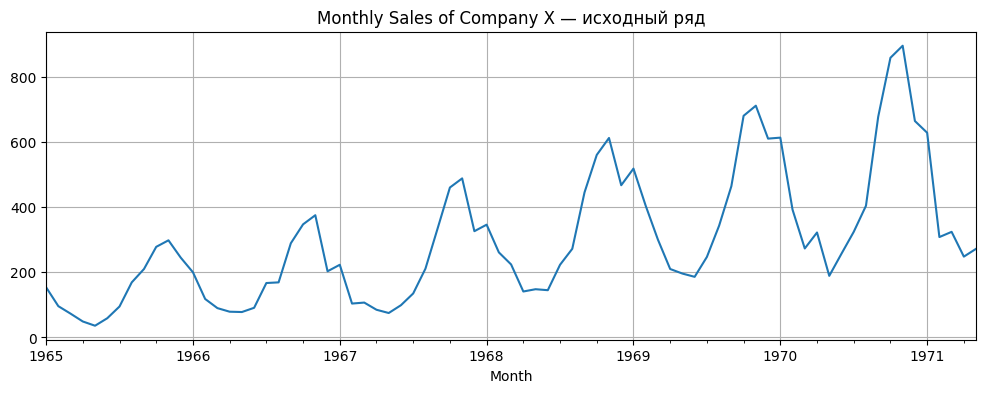

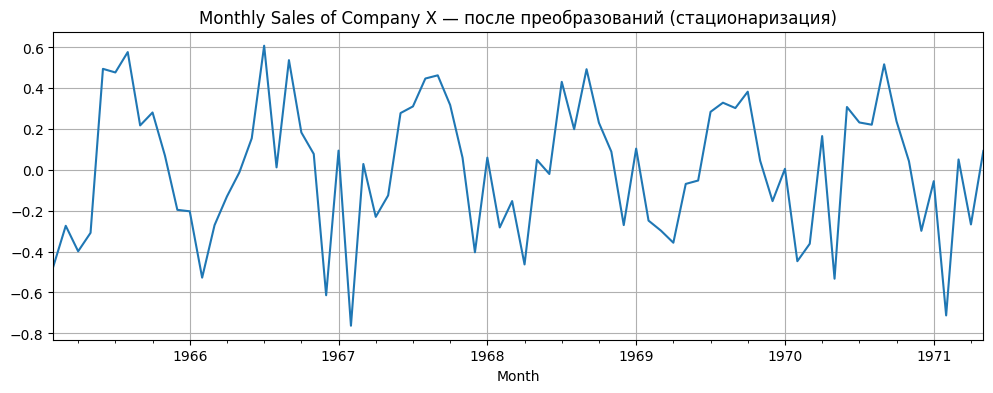

[(Monthly Sales of Company X)] lags=40 -> using 37 (n=76)


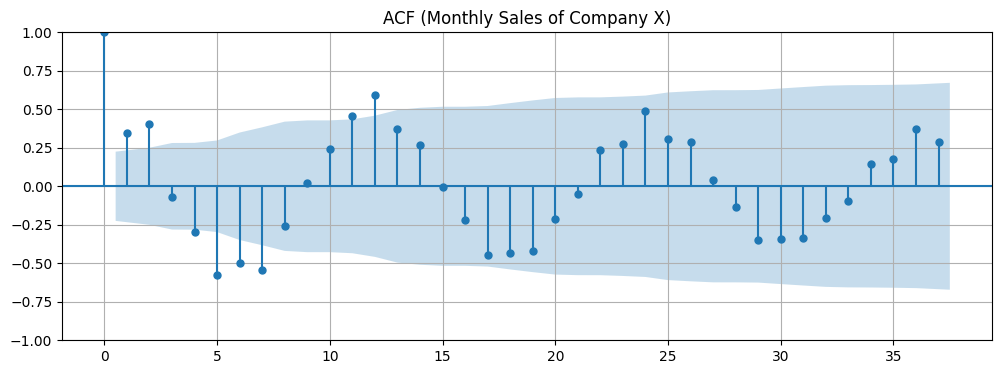

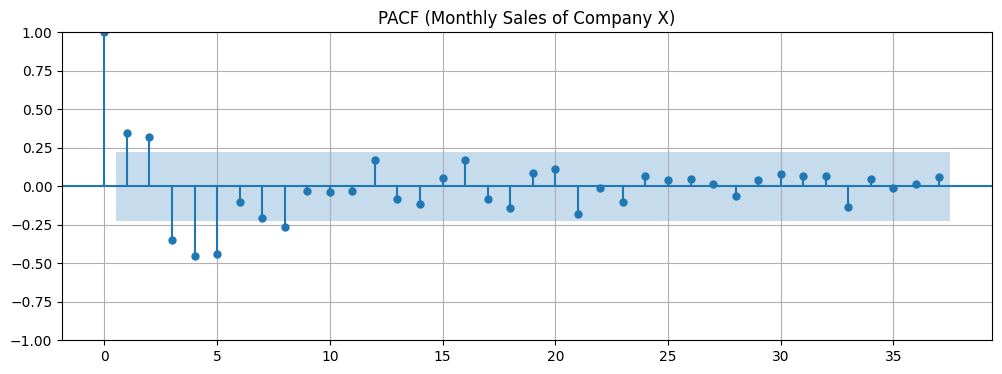

Monthly Boston Armed Robberies
Файл: monthly-boston-armed-robberies-j.csv | Длина: 118 | Частота: MS | Seasonal period: 12
Исходный ряд: ADF: stat=1.001, p=0.9943 | KPSS: stat=1.712, p=0.0100
Шаги: log -> diff1
Итог: ADF: stat=-7.602, p=0.0000 | KPSS: stat=0.090, p=0.1000


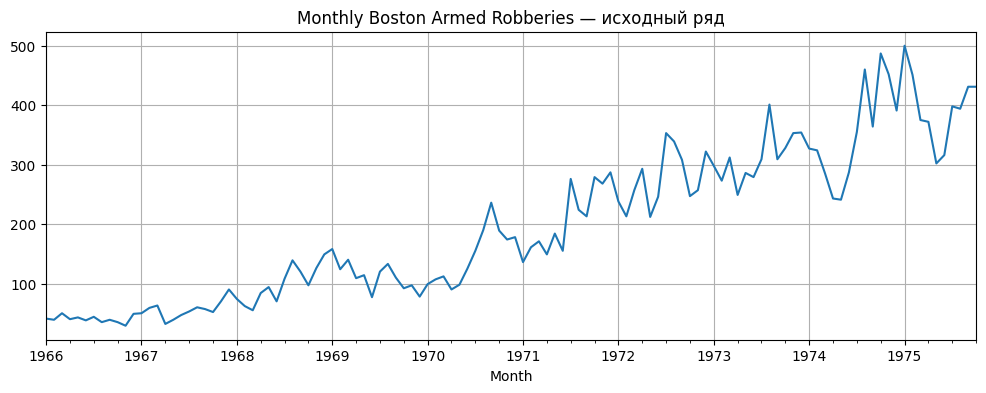

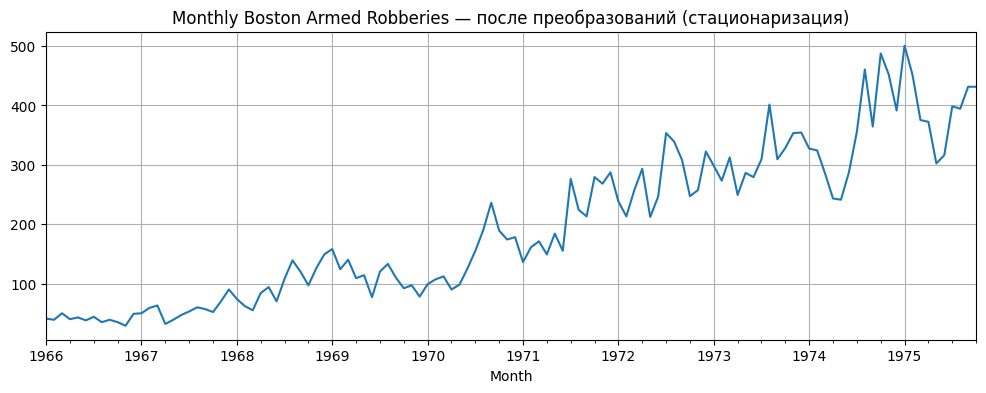

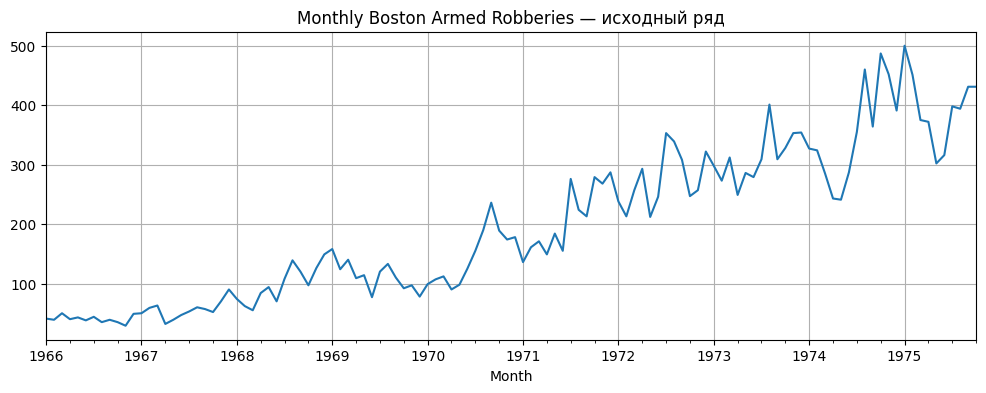

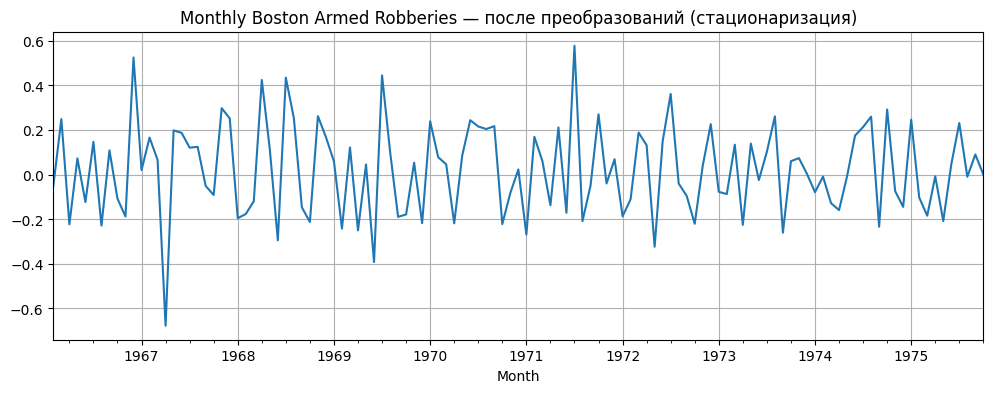

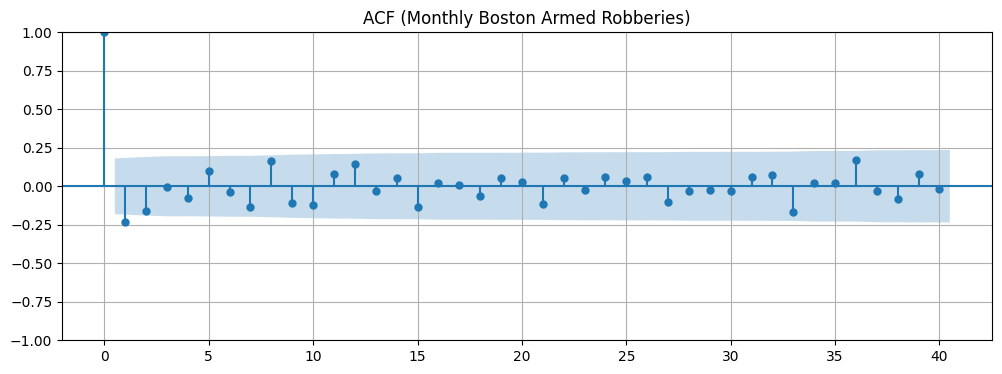

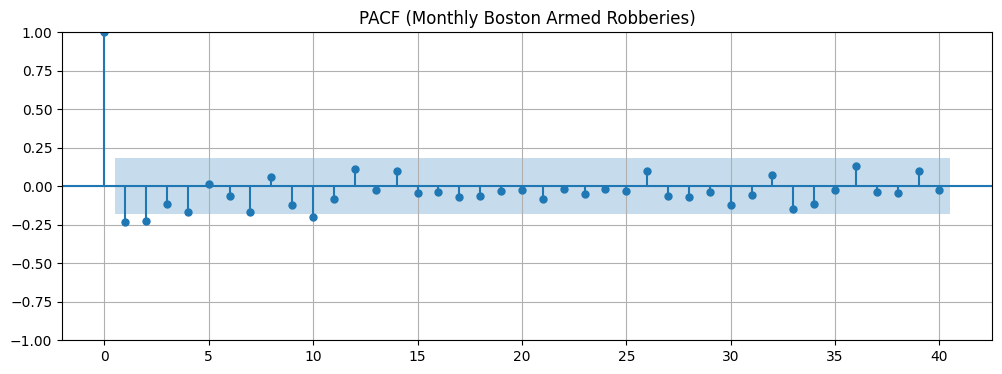

International Airline Passengers
Файл: international-airline-passengers.csv | Длина: 144 | Частота: MS | Seasonal period: 12
Исходный ряд: ADF: stat=0.815, p=0.9919 | KPSS: stat=1.651, p=0.0100
Шаги: log -> diff1 -> seasdiff12
Итог: ADF: stat=-4.443, p=0.0002 | KPSS: stat=0.073, p=0.1000


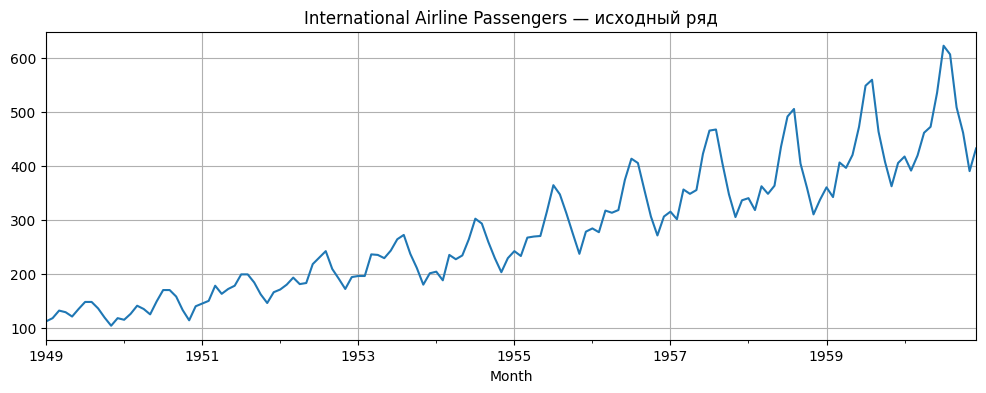

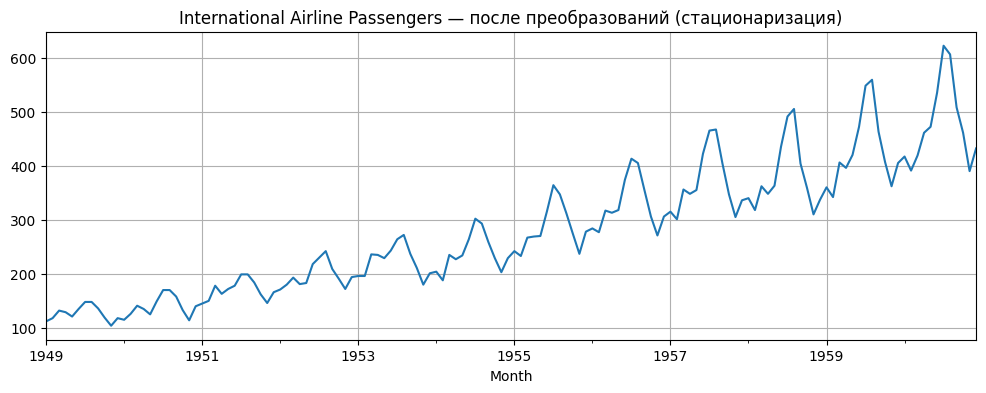

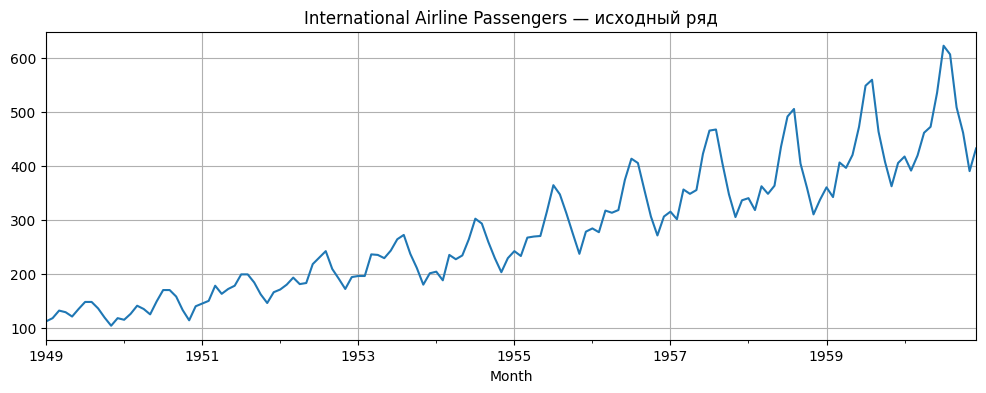

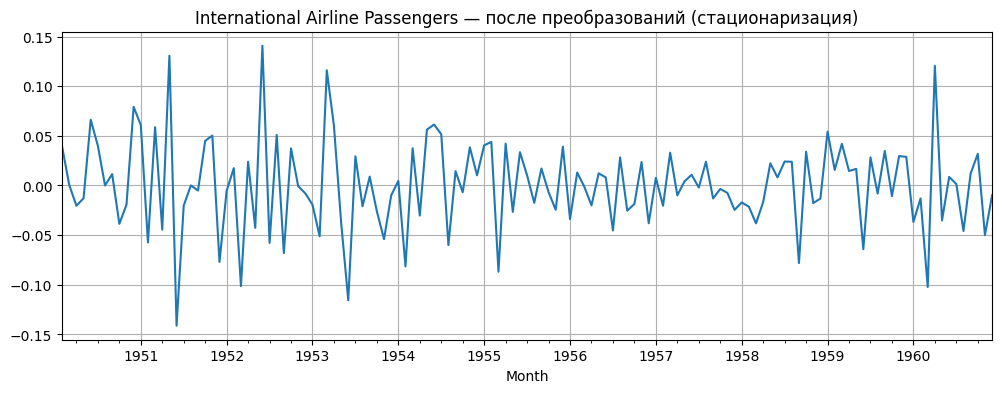

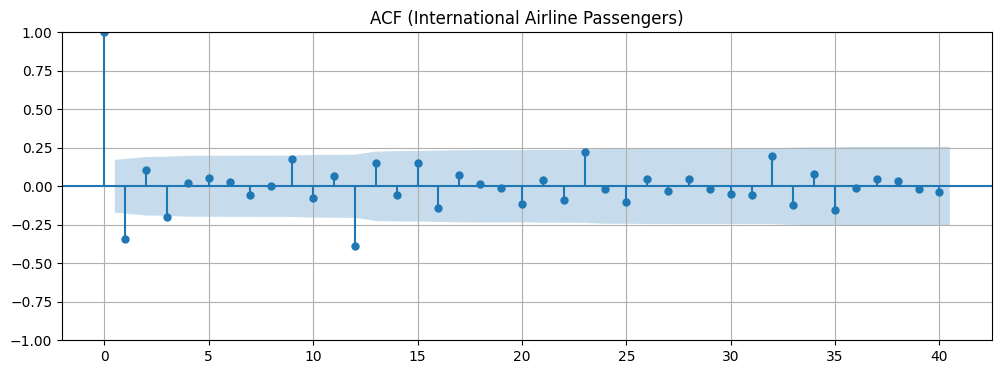

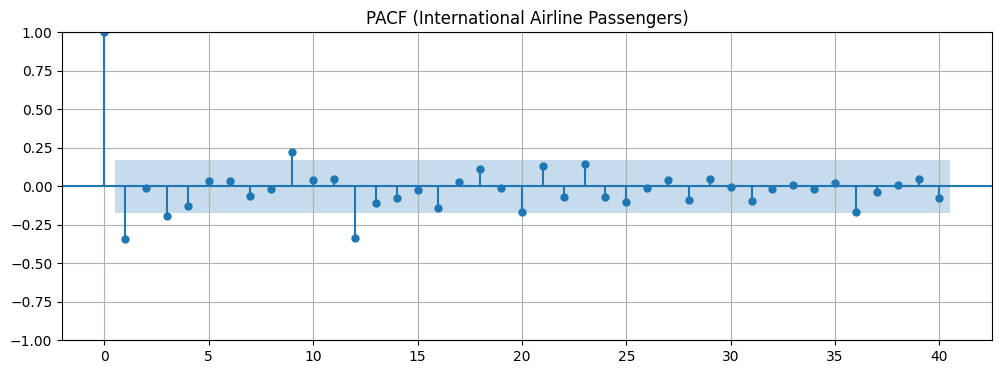

Mean Monthly Air Temperature
Файл: mean-monthly-air-temperature-deg.csv | Длина: 240 | Частота: MS | Seasonal period: 12
Исходный ряд: ADF: stat=-3.255, p=0.0170 | KPSS: stat=0.044, p=0.1000
Шаги: (ничего не делали, уже стационарен)
Итог: ADF: stat=-3.255, p=0.0170 | KPSS: stat=0.044, p=0.1000


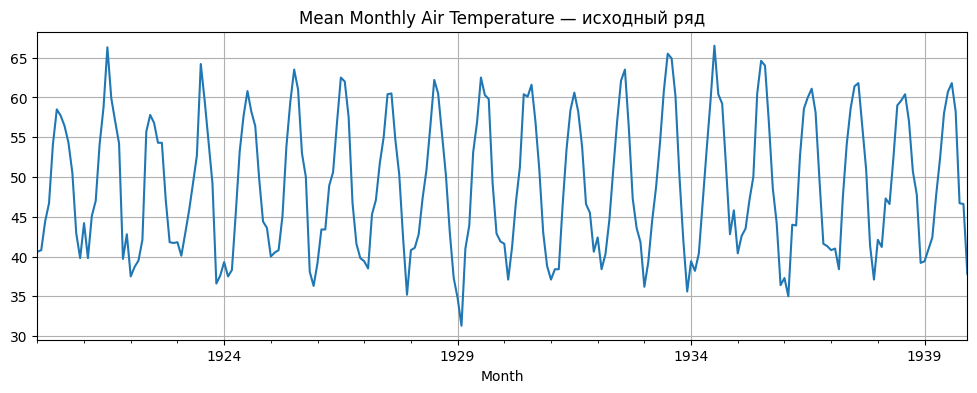

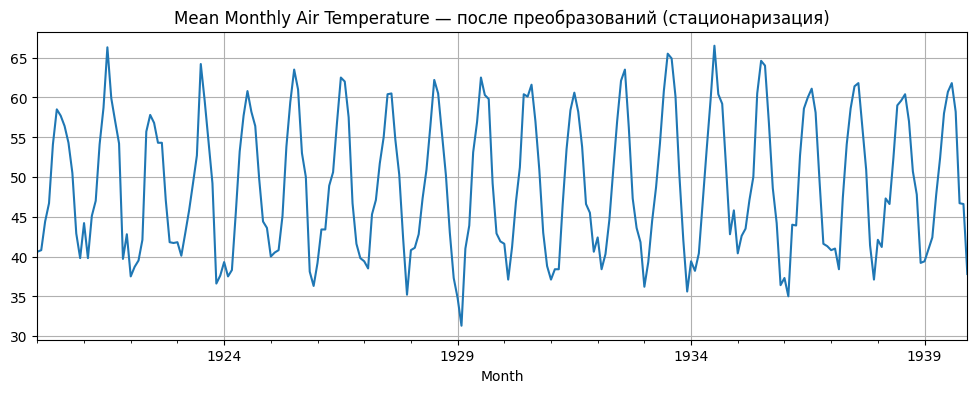

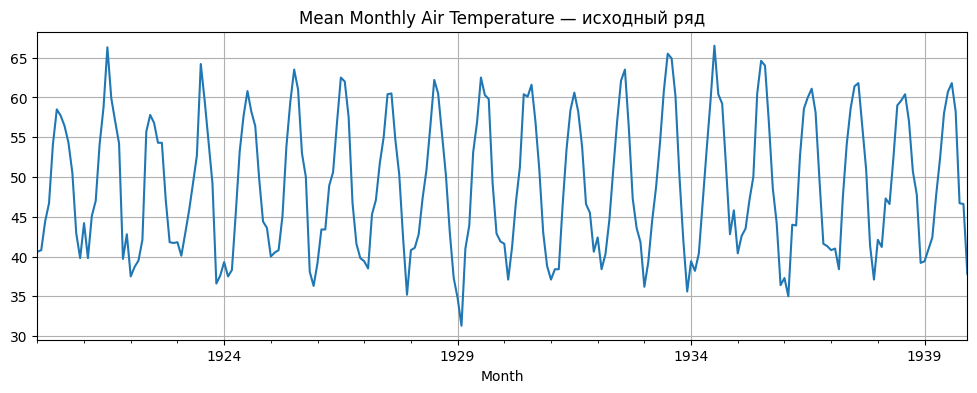

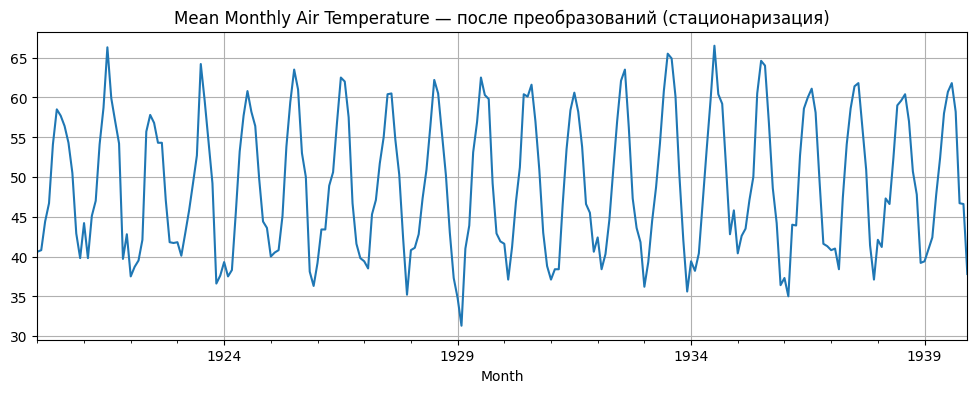

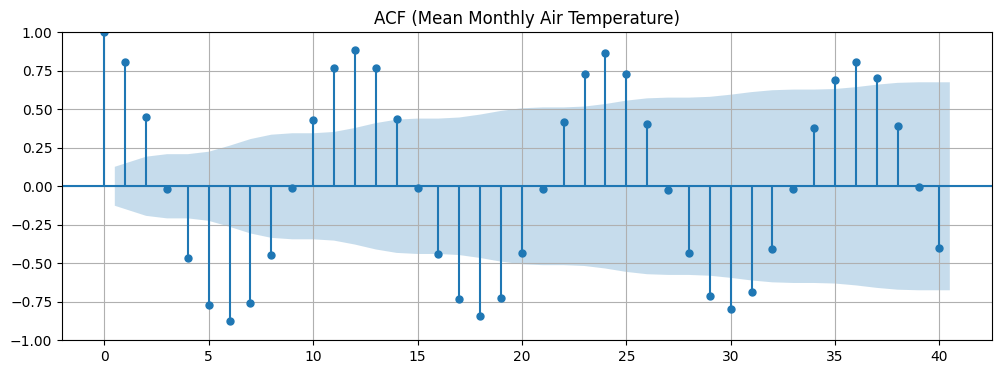

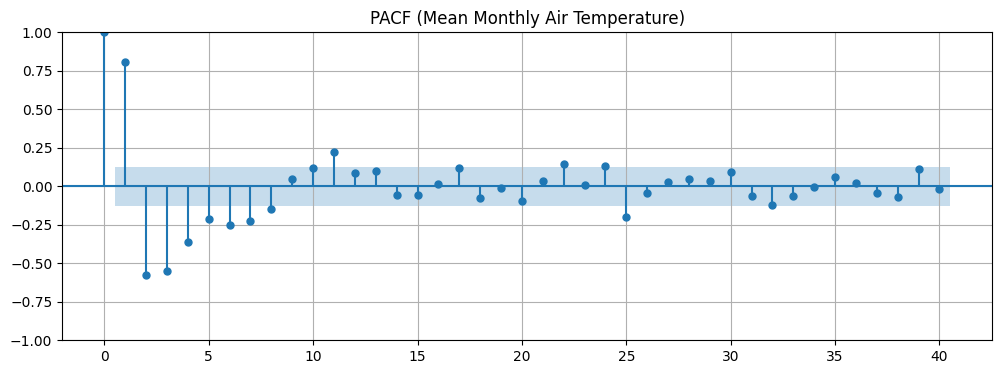

Weekly Closings of the Dow Jones
Файл: weekly-closings-of-the-dowjones-.csv | Длина: 162 | Частота: W-MON | Seasonal period: 52
Исходный ряд: ADF: stat=-1.315, p=0.6225 | KPSS: stat=0.583, p=0.0241
Шаги: diff1
Итог: ADF: stat=-13.025, p=0.0000 | KPSS: stat=0.185, p=0.1000


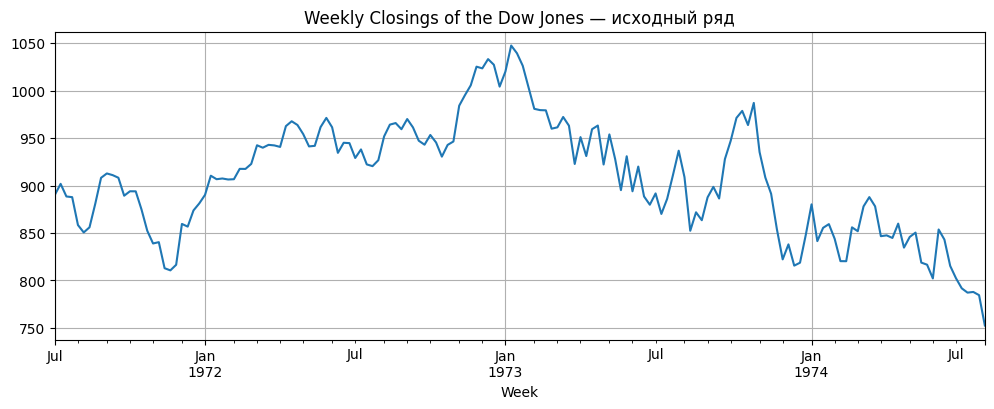

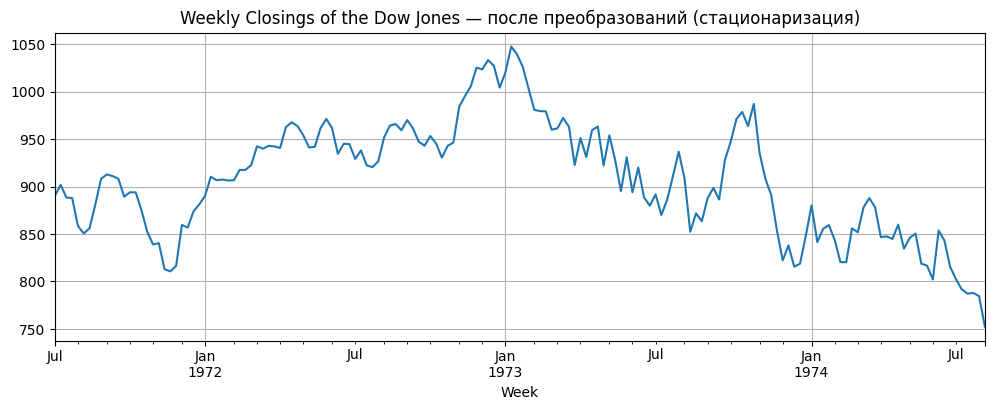

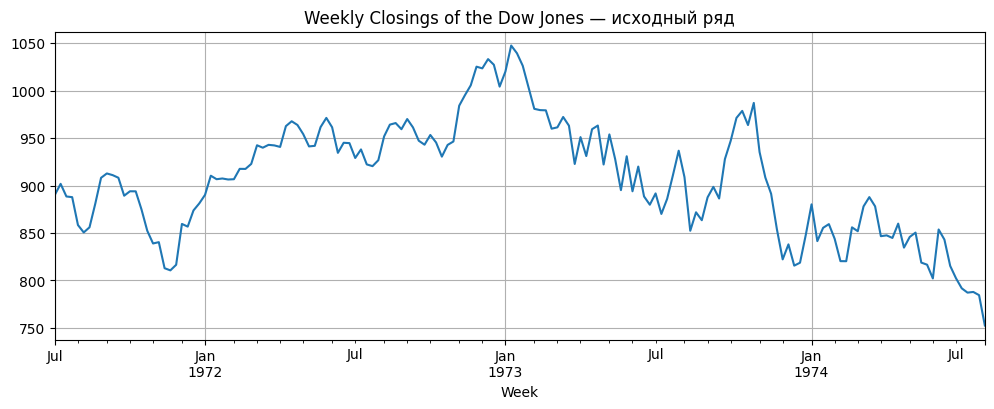

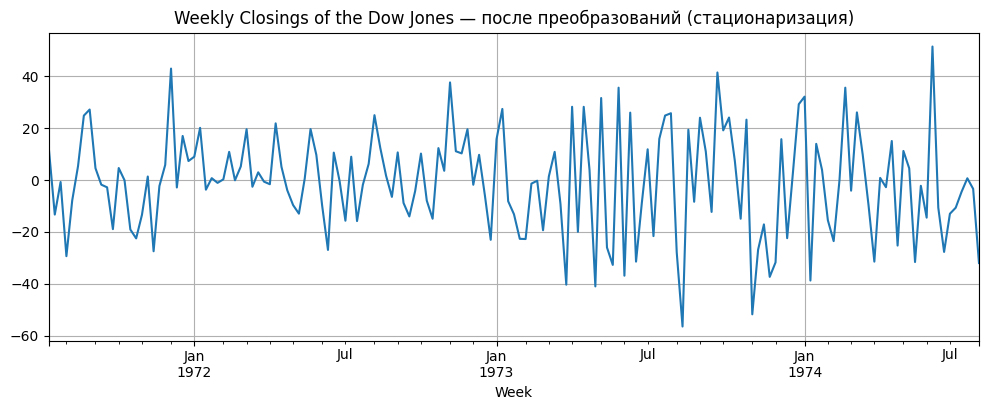

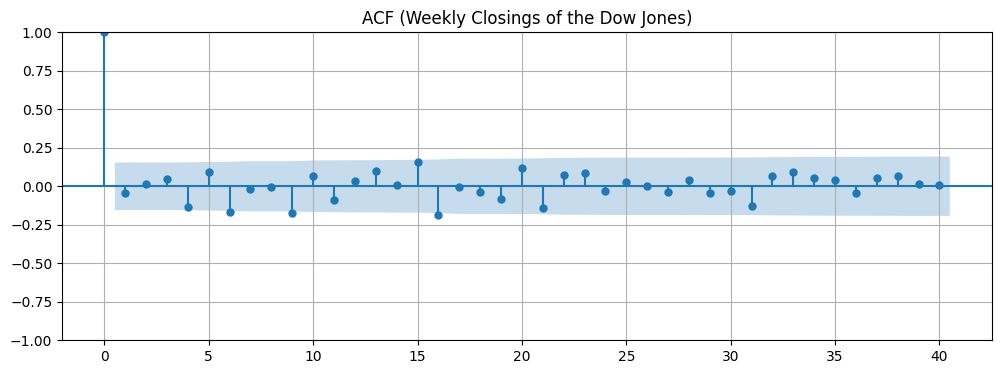

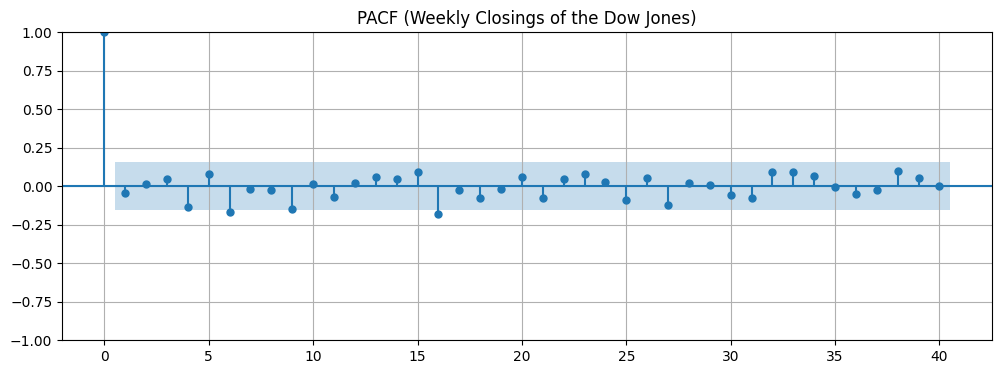

Daily Total Female Births (CA)
Файл: daily-total-female-births-in-cal.csv | Длина: 365 | Частота: D | Seasonal period: 7
Исходный ряд: ADF: stat=-4.808, p=0.0001 | KPSS: stat=1.613, p=0.0100
Шаги: log -> diff1
Итог: ADF: stat=-12.963, p=0.0000 | KPSS: stat=0.198, p=0.1000


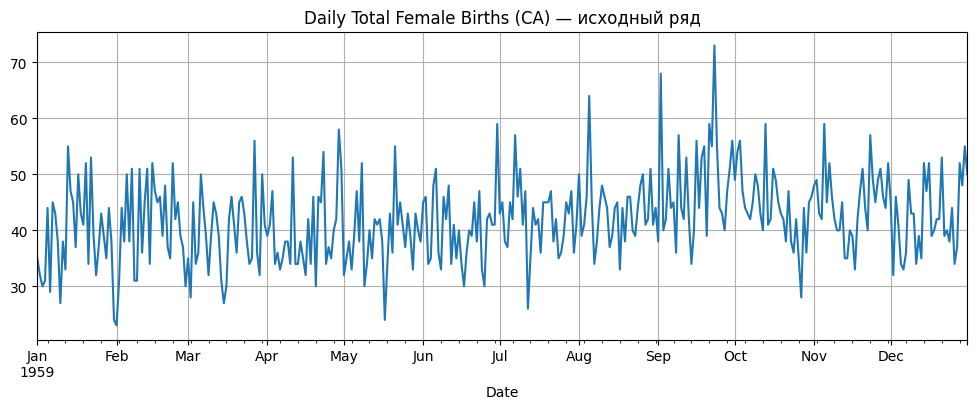

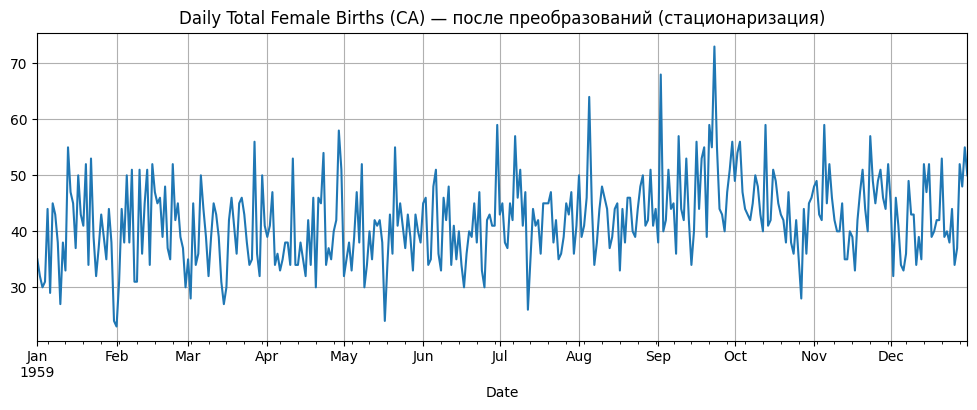

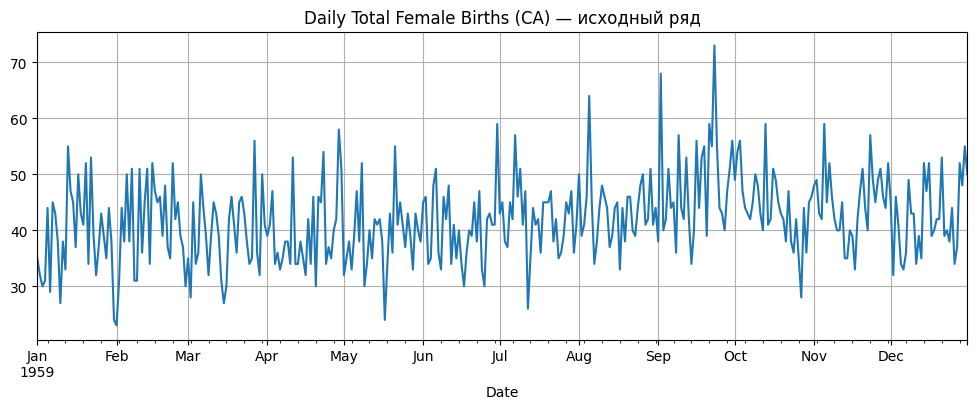

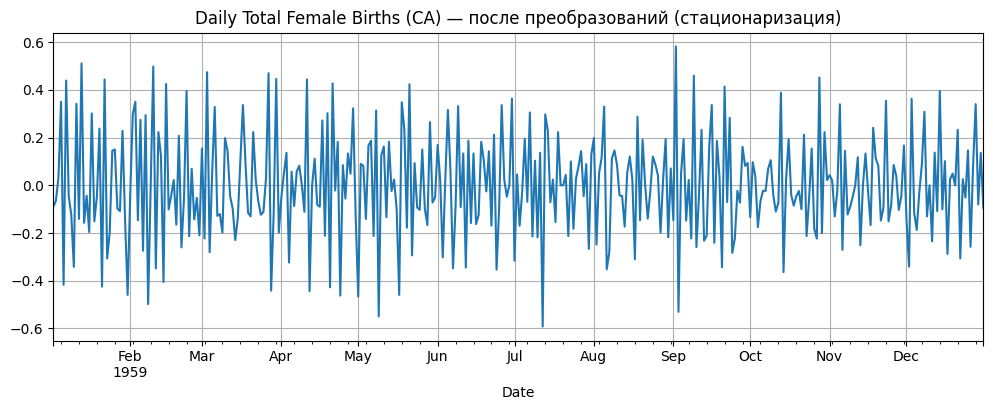

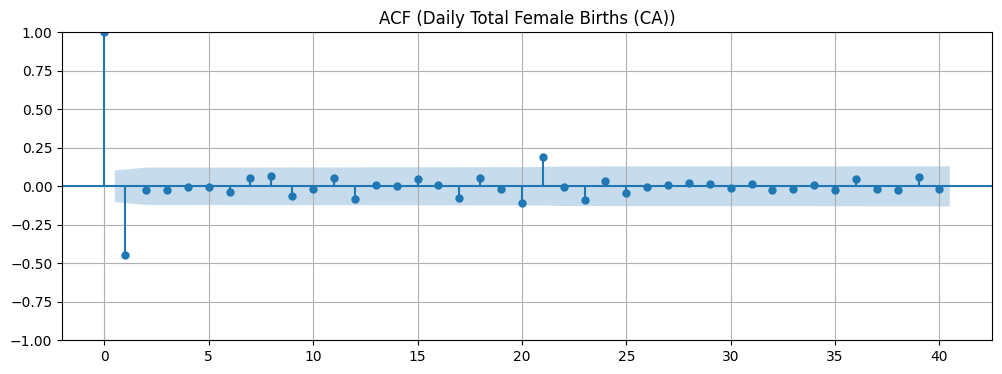

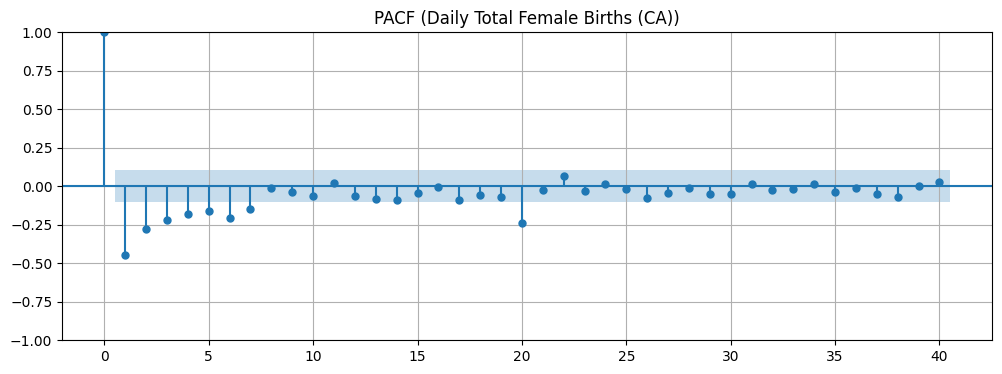

,series,n,freq,seasonal_period,steps,adf_p_raw,kpss_p_raw,adf_p_final,kpss_p_final
5,Daily Total Female Births (CA),365,D,7,log -> diff1,0.000052,0.010000,3.191205e-24,0.1
2,International Airline Passengers,144,MS,12,log -> diff1 -> seasdiff12,0.991880,0.010000,2.485912e-04,0.1
3,Mean Monthly Air Temperature,240,MS,12,already_stationary,0.016989,0.100000,1.698903e-02,0.1
1,Monthly Boston Armed Robberies,118,MS,12,log -> diff1,0.994278,0.010000,2.378602e-11,0.1
0,Monthly Sales of Company X,77,MS,12,log -> diff1,0.988889,0.010000,2.402539e-02,0.1
4,Weekly Closings of the Dow Jones,162,W-MON,52,diff1,0.622455,0.024143,2.407586e-24,0.1


In [21]:
results = {}
summary_rows = []

for name, path in paths.items():
    y = load_series(path)

    # сезонный период по умолчанию (эвристика)
    if y.index.freqstr and y.index.freqstr.startswith("MS"):
        sp = 12
    elif y.index.freqstr and y.index.freqstr.startswith("W"):
        sp = 52
    elif y.index.freqstr == "D":
        sp = 7
    else:
        sp = None

    print("="*90)
    print(name)
    print(f"Файл: {os.path.basename(path)} | Длина: {len(y)} | Частота: {y.index.freqstr} | Seasonal period: {sp}")

    # Тесты на исходном (с константой)
    t_raw = stationarity_tests(y, regression="c")
    print("Исходный ряд:", pretty_tests(t_raw))

    # Стационаризация
    out = make_stationary(y, seasonal_period=sp, regression="c")
    results[name] = out

    print("Шаги:", " -> ".join(out["steps"]) if out["steps"] else "(ничего не делали, уже стационарен)")

    # Итоговые тесты
    t_fin = stationarity_tests(out["stationary"], regression="c")
    print("Итог:", pretty_tests(t_fin))

    # Визуализации
    plot_before_after(y, y, title=name)
    plot_before_after(y, out["stationary"], title=name)
    plot_acf_pacf(out["stationary"], lags=40, title=f"({name})")

    summary_rows.append({
        "series": name,
        "n": len(y),
        "freq": y.index.freqstr,
        "seasonal_period": sp,
        "steps": " -> ".join(out["steps"]) if out["steps"] else "already_stationary",
        "adf_p_raw": t_raw["adf_p"],
        "kpss_p_raw": t_raw["kpss_p"],
        "adf_p_final": t_fin["adf_p"],
        "kpss_p_final": t_fin["kpss_p"],
    })

summary = pd.DataFrame(summary_rows).sort_values("series")
summary


In [23]:
PROJECT_DIR = Path.cwd().parent

out_dir = PROJECT_DIR / "data" / "processed" 
out_dir.mkdir(parents=True, exist_ok=True)

for name, out in results.items():
    st = out["stationary"].dropna()

    fname = (
        name.lower()
        .replace(" ", "_")
        .replace("(", "")
        .replace(")", "")
        .replace("/", "_")
        .replace("__", "_")
        + "_stationary.csv"
    )

    st.to_frame("value").to_csv(out_dir / fname, index_label="date")

print("Готово. Файлы со стационарными рядами:", out_dir)

Готово. Файлы со стационарными рядами: d:\Projects\Project_neto_time\data\processed
